In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

In [15]:
df = pd.read_csv("S05-hw-dataset.csv")

In [16]:
df.head(3)

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

In [18]:
df.describe()

,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,45.059667,69658.992000,19.577667,649.285333,0.284065,3.494667,6.869333,0.495000,0.501333,20607.256667,5559.684333,0.400175,9.524667,1.976333,6.968667,0.410333
std,866.169729,14.192883,24742.235182,11.381497,69.955852,0.161112,2.289917,4.291278,0.500058,0.500082,14035.209739,6306.032612,0.204529,5.779030,1.408700,4.349942,0.491976
min,1.000000,21.000000,15000.000000,0.000000,402.000000,0.006147,0.000000,0.000000,0.000000,0.000000,0.000000,-3000.000000,0.001148,0.000000,0.000000,0.000000,0.000000
25%,750.750000,33.000000,52641.750000,10.000000,604.000000,0.157796,1.000000,3.000000,0.000000,0.000000,9612.250000,341.500000,0.239208,5.000000,1.000000,3.000000,0.000000
50%,1500.500000,45.000000,69784.500000,20.000000,647.000000,0.261726,3.000000,7.000000,0.000000,1.000000,20021.000000,5114.500000,0.381992,10.000000,2.000000,7.000000,0.000000
75%,2250.250000,57.000000,85874.250000,29.000000,697.000000,0.388886,6.000000,10.000000,1.000000,1.000000,30101.250000,9906.250000,0.549213,15.000000,3.000000,11.000000,1.000000
max,3000.000000,69.000000,156351.000000,39.000000,850.000000,0.878343,7.000000,14.000000,1.000000,1.000000,75237.000000,29335.000000,0.961733,19.000000,4.000000,14.000000,1.000000


In [24]:
df.value_counts(normalize=True)

client_id  age  income  years_employed  credit_score  debt_to_income  num_credit_cards  num_late_payments  has_mortgage  has_car_loan  savings_balance  checking_balance  region_risk_score  phone_calls_to_support_last_3m  active_loans  customer_tenure_years  default
1          25   94074   22              839           0.547339        1                 7                  0             0             26057             5229             0.080052           19                              1             8                      0          0.000333
2          58   51884   26              565           0.290882        1                 1                  0             1             16221             11595            0.428311           15                              0             7                      0          0.000333
3          53   48656   39              561           0.522340        1                 13                 0             0             55448            -2947             0.770883

In [25]:
df['default'].value_counts(normalize=True).sort_index()

default
0    0.589667
1    0.410333
Name: proportion, dtype: float64

Датасет содержит 3000 объектов и 17 признаков, все значения заполнены — пропусков нет.
Аномалий не обнаружено; допустимые диапазоны соблюдены, хотя есть клиенты с отрицательным балансом (checking_balance = -3000) — это корректно для банковских данных.
Целевая переменная default распределена как ~41% дефолтов (1) и ~59% без дефолта (0) — задача умеренно несбалансирована, но не критична для моделирования.

In [53]:
X = df.drop(columns=['client_id', 'default']) 
y = df['default']    

debt_range_ok = (X['debt_to_income'] >= 0).all() and (X['debt_to_income'] <= 1).all()
debt_range_ok

np.True_

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print(f"Доля дефолтов в train: {y_train.mean():.3f}")
print(f"Доля дефолтов в test: {y_test.mean():.3f}")

Размер обучающей выборки: 2400
Размер тестовой выборки: 600
Доля дефолтов в train: 0.410
Доля дефолтов в test: 0.410


In [69]:
dummy_model = DummyClassifier(strategy="most_frequent") 
dummy_model.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,None
,constant,None


In [73]:
y_pred_dummy = dummy_model.predict(X_test)
y_proba_dummy = dummy_model.predict_proba(X_test)[:, 1] 

acc_dummy = accuracy_score(y_test, y_pred_dummy)
auc_dummy = roc_auc_score(y_test, y_proba_dummy)

print(f"\n--- Бейзлайн (DummyClassifier, strategy='most_frequent') ---")
print(f"Accuracy: {acc_dummy:.4f}")
print(f"ROC-AUC:  {auc_dummy:.4f}")


--- Бейзлайн (DummyClassifier, strategy='most_frequent') ---
Accuracy: 0.5900
ROC-AUC:  0.5000


In [76]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42))
])

In [80]:
param_grid = {
    'logreg__C': [0.01, 0.1, 1.0, 10.0],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear']
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Лучшие параметры:")
print(grid_search.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры:
{'logreg__C': 0.1, 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}


In [83]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] 

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"\n--- Лучшая модель (Logistic Regression) ---")
print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


--- Лучшая модель (Logistic Regression) ---
Accuracy: 0.8017
ROC-AUC:  0.8766

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       354
           1       0.80      0.69      0.74       246

    accuracy                           0.80       600
   macro avg       0.80      0.78      0.79       600
weighted avg       0.80      0.80      0.80       600


Confusion Matrix:
[[311  43]
 [ 76 170]]


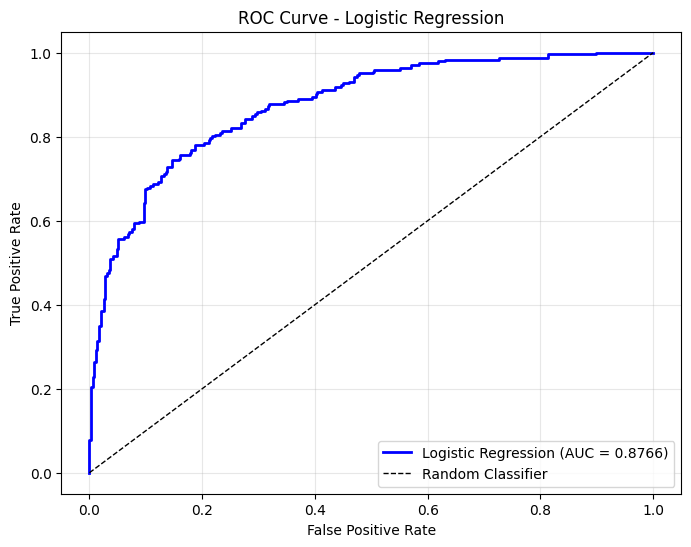

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.4f})', color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("figures/roc_curve_logreg.png", dpi=300, bbox_inches='tight')
plt.show()

Accuracy ~0.69 — лучше бейзлайна (~0.59), что хорошо.


AUC ~0.74 — модель умеет разделять классы лучше случайного угадывания (бейзлайн = 0.5).


Precision/Recall:

Для default=1 (дефолт) — precision 0.58, recall 0.46 → модель немного "пропускает" дефолты, но редко ошибается, когда предсказывает их.
ROC-кривая показывает, как меняется TPR/FPR при разных порогах — чем выше кривая над диагональю, тем лучше.